# Topography Correction



Here, we show how to use 'harmonica' https://www.fatiando.org/harmonica/latest/ to remove topography effect

See https://www.fatiando.org/harmonica/latest/user_guide/topographic_correction.html for more information

In [1]:
# Load necessary package 
import harmonica as hm
import pandas as pd
import pyproj
import matplotlib.pyplot as plt
import numpy as np
import verde as vd

C:\Users\li353\AppData\Local\miniforge3\envs\cage\lib\site-packages\verde\datasets\sample_data.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Read in Free Air Gravity Disturbance after normal earth correction

In [2]:
#Read in Gravity data after drift correction
Data = pd.read_csv('Free_Air_Grav_CAGE_FIELD.csv', delimiter=r',')

In [3]:
# Let's look few line of the data
Data.head()

,Name,Lon,Lat,Height_Ellipsoid,Height_Sea_Level,Total Gravity,Free Air Disturbance
0,L1_S100,116.215892,-31.521237,218.952,247.855,-0.766230,-0.674237
1,L1_S200,116.214864,-31.521183,216.100,245.010,0.020231,-0.763659
2,L1_S300,116.213828,-31.521228,211.371,240.290,0.737294,-1.509716
3,L1_S400,116.212786,-31.521207,210.479,239.400,0.717150,-1.803505
4,L1_S500,116.211679,-31.521218,211.715,240.650,0.249746,-1.890320


# Topography correction

We need to remove the 3D topography mass from the Free Air disturbance. Here we use DEM from global topography grid to do that. You could use high resolution topography grid in your own study area.

Important: Remember to match the topography resolution with gravity

In [4]:
import rasterio

In [5]:
# Load fine resolution topography grid
import xarray as xr
topography = xr.load_dataarray('dem_50m_wgs84.tif')
# Load the coaser dem array
topography_far = xr.load_dataarray('dem.tif')


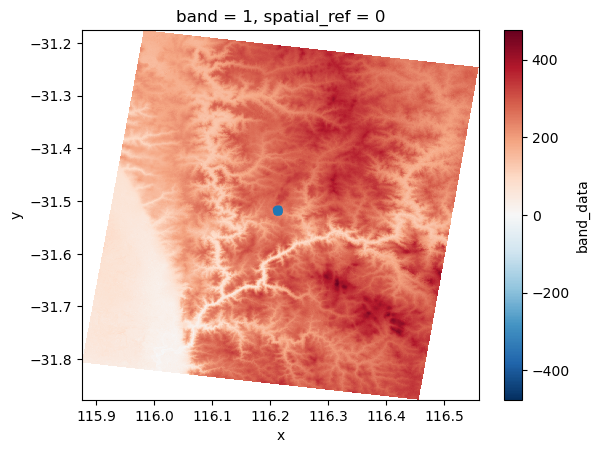

In [6]:
topography.plot()
plt.plot(Data.Lon,Data.Lat,'.')

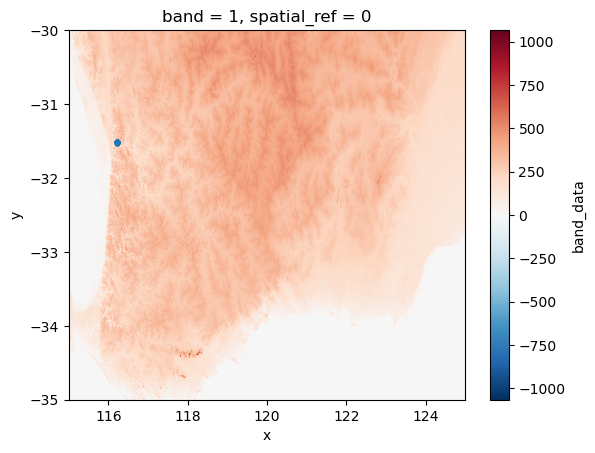

In [7]:
topography_far.plot()
plt.plot(Data.Lon,Data.Lat,'.')

In [8]:
topography

<xarray.DataArray 'band_data' (band: 1, y: 1475, x: 1438)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * band         (band) int32 4B 1
  * x            (x) float64 12kB 115.9 115.9 115.9 115.9 ... 116.6 116.6 116.6
  * y            (y) float64 12kB -31.18 -31.18 -31.18 ... -31.88 -31.88 -31.88
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area

In [9]:
# Let's crop dem it to the gravity region (slightly larger):
region = vd.get_region((Data.Lon, Data.Lat))
region_pad = vd.pad_region(region, pad=0.2)

topography = topography[0].sel(
    x=slice(region_pad[0], region_pad[1]),
    y=slice(region_pad[3], region_pad[2]),
)
topography

<xarray.DataArray 'band_data' (y: 858, x: 855)> Size: 3MB
array([[200.3375  , 200.9685  , 200.9685  , ..., 286.22754 , 284.32394 ,
        286.95404 ],
       [199.79434 , 200.81633 , 200.00038 , ..., 284.83203 , 280.969   ,
        284.0138  ],
       [198.67241 , 199.6041  , 200.18196 , ..., 286.14343 , 282.72974 ,
        282.1446  ],
       ...,
       [ 25.431486,  23.527714,  21.484243, ..., 381.71033 , 382.86008 ,
        382.47348 ],
       [ 25.447445,  24.44722 ,  22.23468 , ..., 384.28815 , 384.28815 ,
        384.53732 ],
       [ 23.747334,  26.185991,  25.394068, ..., 384.4878  , 384.14658 ,
        384.14658 ]], dtype=float32)
Coordinates:
    band         int32 4B 1
  * x            (x) float64 7kB 116.0 116.0 116.0 116.0 ... 116.4 116.4 116.4
  * y            (y) float64 7kB -31.31 -31.31 -31.31 ... -31.72 -31.72 -31.72
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area

In [10]:
# Let's crop dem it to the gravity region (slightly larger):
region = vd.get_region((Data.Lon, Data.Lat))
region_pad = vd.pad_region(region, pad=1.5)

topography_far = topography_far[0].sel(
    x=slice(region_pad[0], region_pad[1]),
    y=slice(region_pad[3], region_pad[2]),
)
topography_far

<xarray.DataArray 'band_data' (y: 301, x: 272)> Size: 327kB
array([[  5.,   6.,  14., ..., 332., 339., 343.],
       [  4.,   5.,  11., ..., 329., 346., 356.],
       [ 12.,   3.,   1., ..., 334., 345., 365.],
       ...,
       [  0.,   0.,   0., ..., 340., 336., 331.],
       [  0.,   0.,   0., ..., 344., 338., 342.],
       [  0.,   0.,   0., ..., 350., 341., 356.]], dtype=float32)
Coordinates:
    band         int32 4B 1
  * x            (x) float64 2kB 115.0 115.0 115.0 115.0 ... 117.7 117.7 117.7
  * y            (y) float64 2kB -30.02 -30.02 -30.04 ... -32.99 -33.0 -33.02
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area

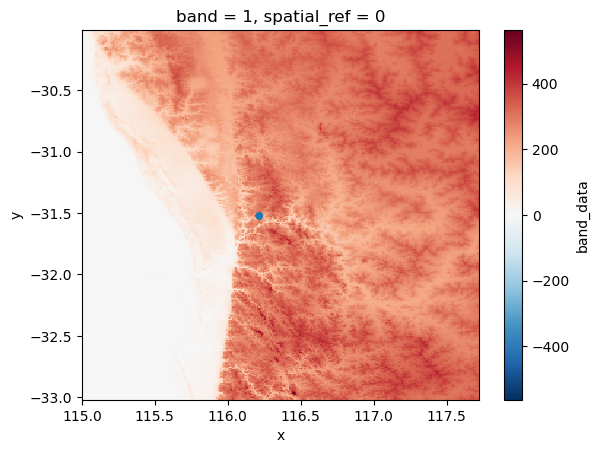

In [11]:
topography_far.plot()
plt.plot(Data.Lon,Data.Lat,'.')

In [12]:
# Define the projection
projection = pyproj.Proj('EPSG:28350')

# Project the topography grid use verde
topography_proj = vd.project_grid(topography.dropna(dim='x').dropna(dim='y'), projection, method="nearest")
topography_proj


<xarray.DataArray 'band_data' (northing: 858, easting: 855)> Size: 3MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * easting   (easting) float64 7kB 4.058e+05 4.058e+05 ... 4.446e+05 4.446e+05
  * northing  (northing) float64 7kB 6.49e+06 6.49e+06 ... 6.535e+06 6.535e+06
Attributes:
    metadata:  Generated by Chain(steps=[('mean',\n              BlockReduce(...

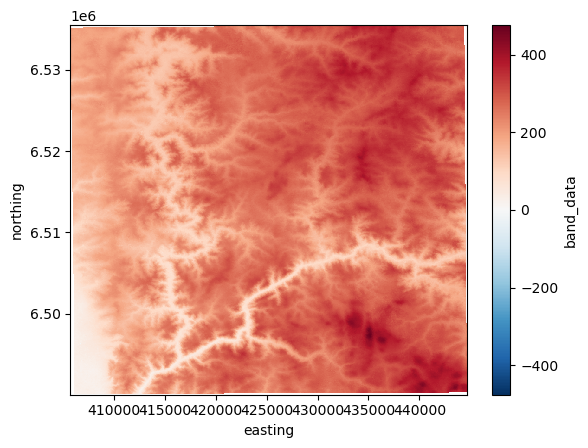

In [13]:
# Now everything is in easting, northing 
topography_proj.plot()

In [14]:
# Define the projection
projection = pyproj.Proj('EPSG:28350')

# Project the topography grid use verde
topography_far_proj = vd.project_grid(topography_far.dropna(dim='x').dropna(dim='y'), projection, method="nearest")
topography_far_proj



<xarray.DataArray 'band_data' (northing: 301, easting: 272)> Size: 327kB
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ...,
       [ nan,   5.,  11., ..., 334., 345.,  nan],
       [ nan,  nan,  nan, ..., 329., 346.,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
  * easting   (easting) float64 2kB 3.076e+05 3.086e+05 ... 5.68e+05 5.69e+05
  * northing  (northing) float64 2kB 6.345e+06 6.346e+06 ... 6.678e+06 6.68e+06
Attributes:
    metadata:  Generated by Chain(steps=[('mean',\n              BlockReduce(...

In [15]:
# We also need to project the gravity location:
# Project the coordinates of the observation points
easting, northing = projection(Data.Lon, Data.Lat)

# Note we need to use Height_Sealevel to match the DEM
coordinates = (easting[0], northing[0], Data['Height_Sea_Level'][0])

In [16]:
np.arange(-10e3,10.01e3,10)

array([-10000.,  -9990.,  -9980., ...,   9980.,   9990.,  10000.])

In [17]:
topo_point_x, topo_point_y = np.meshgrid(np.arange(-10e3,10.1e3,100)+easting[0],np.arange(-10e3,10.1e3,100)+northing[0])

topo_point_far_x, topo_point_far_y = np.meshgrid(np.arange(-100e3,101e3,1000)+easting[0],np.arange(-100e3,101e3,1000)+northing[0])

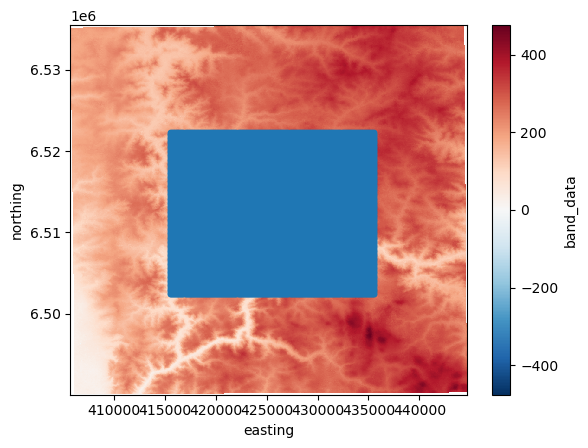

In [18]:
topography_proj.plot()
plt.plot(topo_point_x.flatten(),topo_point_y.flatten(),'.')

In [19]:
topography_proj

<xarray.DataArray 'band_data' (northing: 858, easting: 855)> Size: 3MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * easting   (easting) float64 7kB 4.058e+05 4.058e+05 ... 4.446e+05 4.446e+05
  * northing  (northing) float64 7kB 6.49e+06 6.49e+06 ... 6.535e+06 6.535e+06
Attributes:
    metadata:  Generated by Chain(steps=[('mean',\n              BlockReduce(...

In [20]:
topo_interp = topography_proj.interp(
    easting=("easting", np.arange(-10e3,10.1e3,100)+easting[0]),
    northing=("northing", np.arange(-10e3,10.1e3,100)+northing[0]),
    method="linear"
)

In [21]:
topo_interp_far = topography_far_proj.interp(
    easting=("easting", np.arange(-100e3,101e3,1000)+easting[0]),
    northing=("northing", np.arange(-100e3,101e3,1000)+northing[0]),
    method="linear"
)

In [22]:
x0 = easting[0]
y0 = northing[0]

topo_interp_far = topo_interp_far.where(
    ~(
        (topo_interp_far.easting >= x0 - 10e3) &
        (topo_interp_far.easting <= x0 + 10e3) &
        (topo_interp_far.northing >= y0 - 10e3) &
        (topo_interp_far.northing <= y0 + 10e3)
    )
)

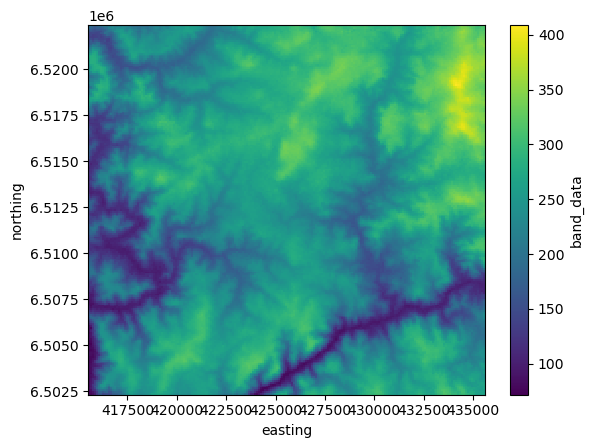

In [23]:
topo_interp.plot()


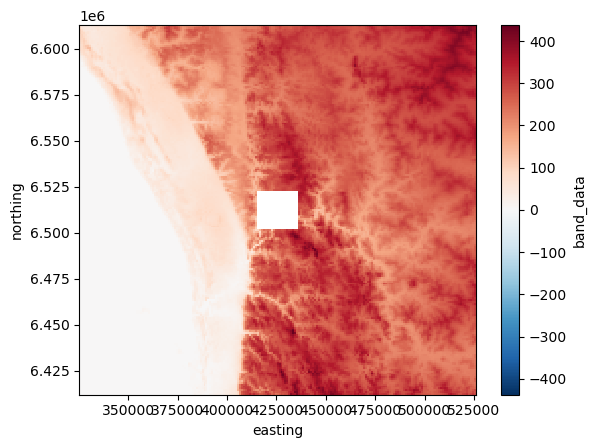

In [24]:
topo_interp_far.plot()

In [25]:
# Match DEM with GPS

topo_interp[101,101]=Data['Height_Sea_Level'][0]

In [26]:
density = np.where(topo_interp >= 0, 2670, 1040 - 2670)

prisms = hm.prism_layer(
    (topo_interp.easting, topo_interp.northing),
    surface=topo_interp,
    reference=0,
    properties={"density": density},
)
prisms

<xarray.Dataset> Size: 811kB
Dimensions:   (northing: 201, easting: 201)
Coordinates:
  * easting   (easting) float64 2kB 4.156e+05 4.157e+05 ... 4.355e+05 4.356e+05
  * northing  (northing) float64 2kB 6.502e+06 6.502e+06 ... 6.522e+06 6.522e+06
    top       (northing, easting) float64 323kB 78.02 76.85 ... 312.4 317.6
    bottom    (northing, easting) float64 323kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    density   (northing, easting) int32 162kB 2670 2670 2670 ... 2670 2670 2670
Attributes:
    coords_units:      meters
    properties_units:  SI

In [27]:
# Compute the terrain effect
terrain_effect = prisms.prism_layer.gravity(coordinates, field="g_z")

In [28]:
terrain_effect

array(27.16814815)

In [29]:
topo_interp_far

<xarray.DataArray 'band_data' (northing: 201, easting: 201)> Size: 323kB
array([[  0.        ,   0.        ,   0.        , ..., 289.17263138,
        305.1752753 , 285.13544754],
       [  0.        ,   0.        ,   0.        , ..., 272.67716317,
        290.6117174 , 279.18564054],
       [  0.        ,   0.        ,   0.        , ..., 260.95868754,
        275.45052026, 289.92769646],
       ...,
       [105.05651979,  80.63984153,  51.88767966, ..., 403.87736699,
        387.33355362, 379.46596691],
       [ 90.60715271,  61.43517814,  49.02179091, ..., 400.30200759,
        382.99347369, 378.17796414],
       [ 83.49313177,  55.28150016,  46.32515782, ..., 403.57297776,
        395.96508781, 382.87260007]])
Coordinates:
  * easting   (easting) float64 2kB 3.256e+05 3.266e+05 ... 5.246e+05 5.256e+05
  * northing  (northing) float64 2kB 6.412e+06 6.413e+06 ... 6.611e+06 6.612e+06
Attributes:
    metadata:  Generated by Chain(steps=[('mean',\n              BlockReduce(...

In [30]:

density = np.where(topo_interp_far >= 0, 2670, 1040 - 2670)

prisms = hm.prism_layer(
    (topo_interp_far.easting, topo_interp_far.northing),
    surface=topo_interp_far,
    reference=0,
    properties={"density": density},
)
prisms

<xarray.Dataset> Size: 811kB
Dimensions:   (northing: 201, easting: 201)
Coordinates:
  * easting   (easting) float64 2kB 3.256e+05 3.266e+05 ... 5.246e+05 5.256e+05
  * northing  (northing) float64 2kB 6.412e+06 6.413e+06 ... 6.611e+06 6.612e+06
    top       (northing, easting) float64 323kB 0.0 0.0 0.0 ... 396.0 382.9
    bottom    (northing, easting) float64 323kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    density   (northing, easting) int32 162kB 2670 2670 2670 ... 2670 2670 2670
Attributes:
    coords_units:      meters
    properties_units:  SI

In [31]:
# Compute the terrain effect
terrain_effect_far = prisms.prism_layer.gravity(coordinates, field="g_z")

In [32]:
terrain_effect_far

array(0.22573039)

In [33]:
terrain_effect=np.zeros(62)
terrain_effect_far=np.zeros(62)


In [34]:
# Now we can loop through all data
for i in np.arange(0,Data.Lon.size,1):
        # We also need to project the gravity location:
    # Project the coordinates of the observation points
    easting, northing = projection(Data.Lon, Data.Lat)
    
    # Note we need to use Height_Sealevel to match the DEM
    coordinates = (easting[i], northing[i], Data['Height_Sea_Level'][i])

    topo_interp = topography_proj.interp(
        easting=("easting", np.arange(-10e3,10.1e3,100)+easting[i]),
        northing=("northing", np.arange(-10e3,10.1e3,100)+northing[i]),
        method="linear"
    )
    topo_interp_far = topography_far_proj.interp(
        easting=("easting", np.arange(-100e3,101e3,1000)+easting[i]),
        northing=("northing", np.arange(-100e3,101e3,1000)+northing[i]),
        method="linear"
    )
    
    x0 = easting[i]
    y0 = northing[i]
    
    topo_interp_far = topo_interp_far.where(
        ~(
            (topo_interp_far.easting >= x0 - 10e3) &
            (topo_interp_far.easting <= x0 + 10e3) &
            (topo_interp_far.northing >= y0 - 10e3) &
            (topo_interp_far.northing <= y0 + 10e3)
        )
    )    
    
    # Match DEM with GPS
    
    topo_interp[101,101]=Data['Height_Sea_Level'][i]
    
    density = np.where(topo_interp >= 0, 2670, 1040 - 2670)
    
    prisms = hm.prism_layer(
        (topo_interp.easting, topo_interp.northing),
        surface=topo_interp,
        reference=0,
        properties={"density": density},
    )
    
    # Compute the terrain effect
    terrain_effect[i] = prisms.prism_layer.gravity(coordinates, field="g_z")
    
    density = np.where(topo_interp_far >= 0, 2670, 1040 - 2670)
    
    prisms = hm.prism_layer(
        (topo_interp_far.easting, topo_interp_far.northing),
        surface=topo_interp_far,
        reference=0,
        properties={"density": density},
    )
    
    terrain_effect_far[i] = prisms.prism_layer.gravity(coordinates, field="g_z")

In [35]:
# The topography-free gravity disturbance:
topo_free_disturbance = Data['Free Air Disturbance'] - terrain_effect - terrain_effect_far

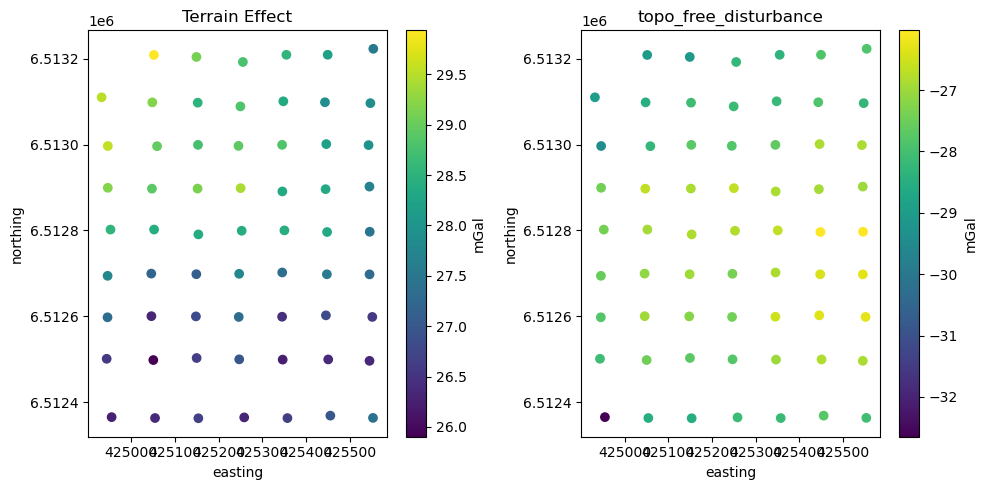

In [36]:
# Creating subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# First subplot: Drift over time
sc = axs[0].scatter(easting, northing, c=terrain_effect+terrain_effect_far, cmap='viridis')
axs[0].set_xlabel('easting')
axs[0].set_ylabel('northing')
axs[0].set_title("Terrain Effect")
plt.colorbar(sc, ax=axs[0], label='mGal')

# Second subplot: Drift for each locations
sc = axs[1].scatter(easting, northing, c=topo_free_disturbance, cmap='viridis')
axs[1].set_xlabel('easting')
axs[1].set_ylabel('northing')
axs[1].set_title("topo_free_disturbance")
plt.colorbar(sc, ax=axs[1], label='mGal')

# Display the plot
plt.tight_layout()
plt.show()

In [37]:
# Save the Data to a CSV file
data_array = np.column_stack((Data['Lon'], Data['Lat'], easting, northing, Data['Height_Ellipsoid'], Data['Height_Sea_Level'], Data['Total Gravity'], Data['Free Air Disturbance'],topo_free_disturbance))
df = pd.DataFrame(data_array, columns=['Lon', 'Lat', 'Easting', 'Northing', 'Height_Ellipsoid', 'Height_Sea_Level', 'Total Gravity', 'Free Air Disturbance','Topo Free Disturbance'])
df.to_csv('Topo_Free_Grav_CAGE_FIELD.csv', index=False)

In the next notebook, we will use the gravity data to run inversion !!!!!!!!!!!!!!!!!!!